# Returns and Benchmarks

Calculates monthly log returns for stocks and benchmarks, then computes excess returns (stock return minus benchmark return). Saves the returns dataset for feature engineering.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Paths & tag 
INTERIM_PATH  = Path("../data/interim")
PROCESSED_PATH = Path("../data/processed")
# 1b for expanded universe
TAG = "1b"   

def resolve_equities_file(tag: str):
    if tag:
        p_parq = INTERIM_PATH / f"equities_1mo_cleaned_data_{tag}.parquet"
        p_csv  = INTERIM_PATH / f"equities_1mo_cleaned_data_{tag}.csv"
    else:
        p_parq = INTERIM_PATH / "equities_1mo_cleaned_data.parquet"
        p_csv  = INTERIM_PATH / "equities_1mo_cleaned_data.csv"
    if p_parq.exists():
        return pd.read_parquet(p_parq)
    if p_csv.exists():
        return pd.read_csv(p_csv, parse_dates=["date"])
    raise FileNotFoundError(f"No equities file found for TAG='{tag}'")

# Benchmarks 
print("Loading SNP data...")
snp_raw = pd.read_csv(INTERIM_PATH / "snp500_1mo_cleaned_data.csv")
print(f"SNP raw shape: {snp_raw.shape}")
print(f"SNP raw columns: {list(snp_raw.columns)}")
print("SNP raw first 3 rows:")
print(snp_raw.head(3))

# Kkip the first row (headers) and use proper column names
snp_data = snp_raw.iloc[2:].copy()  # Skip first 2 rows (headers)
snp_data.columns = ['date', 'Close', 'High', 'Low', 'Open', 'Volume']
snp_data['date'] = pd.to_datetime(snp_data['date'])

# Convert price columns to numeric (they're currently strings)
price_cols = ['Close', 'High', 'Low', 'Open', 'Volume']
for col in price_cols:
    snp_data[col] = pd.to_numeric(snp_data[col], errors='coerce')

snp_data = snp_data.reset_index(drop=True)

print("Loading FTSE data...")
ftse_raw = pd.read_csv(INTERIM_PATH / "ftse_1mo_cleaned_data.csv")
print(f"FTSE raw shape: {ftse_raw.shape}")

# Skip the first row (headers) and use proper column names
ftse_data = ftse_raw.iloc[2:].copy()  # Skip first 2 rows (headers)
ftse_data.columns = ['date', 'Close', 'High', 'Low', 'Open', 'Volume']
ftse_data['date'] = pd.to_datetime(ftse_data['date'])

# Convert price columns to numeric (they're currently strings)
for col in price_cols:
    ftse_data[col] = pd.to_numeric(ftse_data[col], errors='coerce')

ftse_data = ftse_data.reset_index(drop=True)

# Equities (tagged)
equities_basket = resolve_equities_file(TAG)

# Data is now properly loaded with correct date columns
print("Data loaded successfully:")
print(f"SNP columns: {list(snp_data.columns)}")
print(f"FTSE columns: {list(ftse_data.columns)}")
print(f"SNP date range: {snp_data['date'].min()} to {snp_data['date'].max()}")
print(f"FTSE date range: {ftse_data['date'].min()} to {ftse_data['date'].max()}")

print(f"SNP rows: {len(snp_data)} | FTSE rows: {len(ftse_data)} | Equities rows: {len(equities_basket)}")
print(f"Tickers in equities: {equities_basket['ticker'].nunique()}")

# Check data structure
print(f"\nSNP columns: {list(snp_data.columns)}")
print(f"FTSE columns: {list(ftse_data.columns)}")
print(f"Equities columns: {list(equities_basket.columns)}")


Loading SNP data...
SNP raw shape: (251, 6)
SNP raw columns: ['Price', 'Close', 'High', 'Low', 'Open', 'Volume']
SNP raw first 3 rows:
        Price             Close               High      Low  \
0      Ticker             ^GSPC              ^GSPC    ^GSPC   
1        Date               NaN                NaN      NaN   
2  2005-01-31  1181.27001953125  1217.800048828125  1163.75   

                 Open       Volume  
0               ^GSPC        ^GSPC  
1                 NaN          NaN  
2  1211.9200439453125  31498800000  
Loading FTSE data...
FTSE raw shape: (251, 6)
Data loaded successfully:
SNP columns: ['date', 'Close', 'High', 'Low', 'Open', 'Volume']
FTSE columns: ['date', 'Close', 'High', 'Low', 'Open', 'Volume']
SNP date range: 2005-01-31 00:00:00 to 2025-09-30 00:00:00
FTSE date range: 2005-01-31 00:00:00 to 2025-09-30 00:00:00
SNP rows: 249 | FTSE rows: 249 | Equities rows: 24229
Tickers in equities: 100

SNP columns: ['date', 'Close', 'High', 'Low', 'Open', 'Volume']


## Excess Returns

Merges each stock with its regional benchmark (S&P 500 for US, FTSE for UK) and calculates excess log returns.


In [6]:
def calc_mom_log_return(df, close_col="Close", new_col="log_return"):
    """Calculate monthly log returns for a single time series"""
    df = df.sort_values("date").copy()
    prev_close = df[close_col].shift(1)
    df[new_col] = np.log(df[close_col] / prev_close)
    return df

def cal_mom_return_basket(df, group_col="ticker", price_col="close", new_col="log_return"):
    """Calculate monthly log returns for multiple time series grouped by ticker"""
    df = df.sort_values([group_col, "date"]).copy()
    prev = df.groupby(group_col, sort=False)[price_col].shift(1)
    df[new_col] = np.log(df[price_col] / prev)
    return df

# Check if required columns exist before calculating returns
print("=== Checking Column Names ===")
print(f"SNP columns: {list(snp_data.columns)}")
print(f"FTSE columns: {list(ftse_data.columns)}")
print(f"Equities columns: {list(equities_basket.columns)}")

# Check if Close column exists in SNP/FTSE data
if "Close" not in snp_data.columns:
    print("'Close' column not found in SNP data. Available columns:", list(snp_data.columns))
if "Close" not in ftse_data.columns:
    print("'Close' column not found in FTSE data. Available columns:", list(ftse_data.columns))
if "close" not in equities_basket.columns:
    print("'close' column not found in equities data. Available columns:", list(equities_basket.columns))

# Compute monthly log returns
print("\n=== Calculating Log Returns ===")
try:
    snp_data = calc_mom_log_return(snp_data, close_col="Close", new_col="log_return")
    print("SNP log returns calculated")
except Exception as e:
    print(f"SNP error: {e}")

try:
    ftse_data = calc_mom_log_return(ftse_data, close_col="Close", new_col="log_return")
    print("FTSE log returns calculated")
except Exception as e:
    print(f"FTSE error: {e}")

try:
    equities_basket = cal_mom_return_basket(equities_basket, price_col="close", new_col="log_return")
    print("Equities log returns calculated")
except Exception as e:
    print(f"Equities error: {e}")

print(f"\nFinal counts:")
print(f"SNP log returns: {snp_data['log_return'].notna().sum() if 'log_return' in snp_data.columns else 'N/A'}")
print(f"FTSE log returns: {ftse_data['log_return'].notna().sum() if 'log_return' in ftse_data.columns else 'N/A'}")
print(f"Equities log returns: {equities_basket['log_return'].notna().sum() if 'log_return' in equities_basket.columns else 'N/A'}")


=== Checking Column Names ===
SNP columns: ['date', 'Close', 'High', 'Low', 'Open', 'Volume']
FTSE columns: ['date', 'Close', 'High', 'Low', 'Open', 'Volume']
Equities columns: ['date', 'close', 'volume', 'ticker', 'country', 'sector']

=== Calculating Log Returns ===
SNP log returns calculated
FTSE log returns calculated
Equities log returns calculated

Final counts:
SNP log returns: 248
FTSE log returns: 248
Equities log returns: 24129


In [8]:
# Check NaNs
print("NaNs in S&P500", snp_data["log_return"].isna().sum())
print("NaNs in FTSE100", ftse_data["log_return"].isna().sum())

# First-per-ticker NaN (expected for the first month of each series)
first_per_ticker = (
    equities_basket.sort_values(["ticker","date"])
                   .groupby("ticker")["log_return"].head(1).isna().sum()
)
total_nans = equities_basket["log_return"].isna().sum()
print(f"Equities NaNs total: {total_nans} | first-per-ticker: {first_per_ticker} | internal: {total_nans-first_per_ticker}")

# Drop NaNs (keeps the first-month NaNs per ticker out of the set)
snp_data  = snp_data.rename(columns={"log_return": "l_bench"}).dropna(subset=["l_bench"])
ftse_data = ftse_data.rename(columns={"log_return": "l_bench"}).dropna(subset=["l_bench"])
equities_basket = equities_basket.rename(columns={"log_return": "l_stock"}).dropna(subset=["l_stock"])

# Check dates per ticker after drop
ok = equities_basket.sort_values(["ticker","date"]).groupby("ticker")["date"].apply(lambda s: s.is_monotonic_increasing).all()
print("Equities date monotonic per ticker?", bool(ok))

# Recheck NaN after dropping
print("\n After Dropping NaNs: ")
print(f"S&P500: {len(snp_data)} rows, {snp_data['l_bench'].isna().sum()} NaNs")
print(f"FTSE100: {len(ftse_data)} rows, {ftse_data['l_bench'].isna().sum()} NaNs")
print(f"Equities: {len(equities_basket)} rows, {equities_basket['l_stock'].isna().sum()} NaNs")


NaNs in S&P500 1
NaNs in FTSE100 1
Equities NaNs total: 100 | first-per-ticker: 100 | internal: 0
Equities date monotonic per ticker? True

 After Dropping NaNs: 
S&P500: 248 rows, 0 NaNs
FTSE100: 248 rows, 0 NaNs
Equities: 24129 rows, 0 NaNs


In [10]:
def out(name: str, tag: str = TAG):
    stem, ext = name.rsplit(".", 1)
    return INTERIM_PATH / f"{stem}{('_' + tag) if tag else ''}.{ext}"

snp_data[["date","Close","l_bench"]].to_parquet(out("snp500_monthly_with_log_returns.parquet"), index=False)
ftse_data[["date","Close","l_bench"]].to_parquet(out("ftse_monthly_with_log_returns.parquet"), index=False)
equities_basket.to_parquet(out("equities_monthly_with_log_returns.parquet"), index=False)

print("Saved (tagged):")
print(" ", out("snp500_monthly_with_log_returns.parquet").name)
print(" ", out("ftse_monthly_with_log_returns.parquet").name)
print(" ", out("equities_monthly_with_log_returns.parquet").name)


Saved (tagged):
  snp500_monthly_with_log_returns_1b.parquet
  ftse_monthly_with_log_returns_1b.parquet
  equities_monthly_with_log_returns_1b.parquet


In [12]:
# Build benchmark table (unique per date/bench)
bench_snp500 = snp_data[["date", "l_bench"]].copy()
bench_snp500["bench"] = "^GSPC"

bench_ftse = ftse_data[["date", "l_bench"]].copy()
bench_ftse["bench"] = "^FTSE"

benchmark_df = pd.concat([bench_snp500, bench_ftse], ignore_index=True)
benchmark_df = (benchmark_df
                .sort_values(["bench", "date"])
                .drop_duplicates(subset=["bench", "date"], keep="last"))

# Map each equity to its benchmark (vectorised)
is_uk = equities_basket["ticker"].astype(str).str.endswith(".L")
equities_basket["bench"] = np.where(is_uk, "^FTSE", "^GSPC")

# Checks
assert not benchmark_df.duplicated(["bench","date"]).any(), "Duplicate (bench,date) in benchmark_df"
bad_uk = equities_basket.loc[is_uk & (equities_basket["bench"] != "^FTSE")]
bad_us = equities_basket.loc[~is_uk & (equities_basket["bench"] != "^GSPC")]
print(f"UK mis-maps: {len(bad_uk)} | US mis-maps: {len(bad_us)}")

# Show coverage per bench
print(equities_basket["bench"].value_counts())

# Merge equities with their benchmark returns
print("\n=== Merging Equities with Benchmarks ===")
returns_monthly = equities_basket.merge(
    benchmark_df,
    on=["date", "bench"],
    how="left",
    validate="many_to_one"
)

# Calculate excess log returns
returns_monthly["ex_log"] = returns_monthly["l_stock"] - returns_monthly["l_bench"]

print(f"Merged dataset: {len(returns_monthly)} rows")
print(f"Missing benchmark data: {returns_monthly['l_bench'].isna().sum()} rows")
print(f"Excess log returns calculated: {returns_monthly['ex_log'].notna().sum()} rows")


UK mis-maps: 0 | US mis-maps: 0
bench
^GSPC    12069
^FTSE    12060
Name: count, dtype: int64

=== Merging Equities with Benchmarks ===
Merged dataset: 24129 rows
Missing benchmark data: 0 rows
Excess log returns calculated: 24129 rows


In [14]:
keep_cols = ["date","ticker","bench","l_stock","l_bench","ex_log","close","volume"]
returns_monthly = returns_monthly[keep_cols].sort_values(["ticker","date"])

# SAVE (tagged)
returns_path = out("returns_monthly_stocks_2b.parquet")
returns_monthly.to_parquet(returns_path, index=False)

print("Saved returns with ex_log ", returns_path.name)
print(returns_monthly.head())


Saved returns with ex_log  returns_monthly_stocks_2b_1b.parquet
        date ticker  bench   l_stock   l_bench    ex_log        close  \
0 2005-02-28  AAL.L  ^FTSE  0.051415  0.023665  0.027750  1380.772705   
1 2005-03-31  AAL.L  ^FTSE -0.032918 -0.015026 -0.017892  1336.059937   
2 2005-04-30  AAL.L  ^FTSE -0.077620 -0.019122 -0.058499  1236.277344   
3 2005-05-31  AAL.L  ^FTSE  0.122271  0.033242  0.089029  1397.067871   
4 2005-06-30  AAL.L  ^FTSE -0.002289  0.029614 -0.031903  1393.873779   

       volume  
0  21856477.0  
1  12819716.0  
2  27002956.0  
3  44256497.0  
4  13780426.0  


           mean       min       max  count
bench                                     
^FTSE -0.148584 -0.148584 -0.148584     50
^GSPC -0.133668 -0.133668 -0.133668     50

Share of stocks < 0 in Mar-2020: 84.0%


/var/folders/m2/10p9b8xj3gg5xtr6q8r54cs40000gn/T/ipykernel_89792/4161642499.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["^GSPC","^FTSE"])


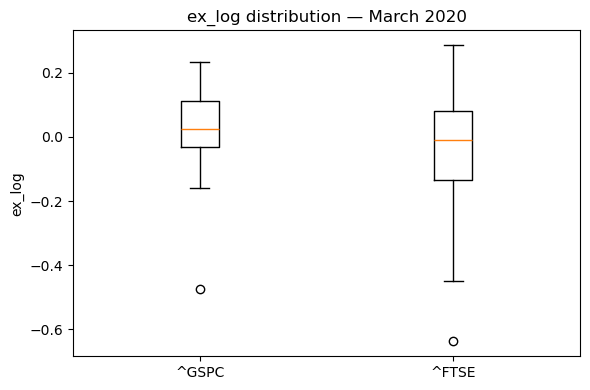

In [16]:
#  March 2020 check

# Filter by month using Periods
m20_mask = returns_monthly["date"].dt.to_period("M") == pd.Period("2020-03")
m20 = returns_monthly.loc[m20_mask].copy()

# Summary by benchmark
print(m20.groupby("bench")["l_bench"].agg(mean="mean", min="min", max="max", count="count"))

# Share of negative stock returns that month
share_neg = (m20["l_stock"] < 0).mean()
print(f"\nShare of stocks < 0 in Mar-2020: {share_neg:.1%}")

# Boxplot of ex_log per benchmark
data = [
    m20.loc[m20["bench"] == "^GSPC", "ex_log"].dropna(),
    m20.loc[m20["bench"] == "^FTSE", "ex_log"].dropna()
]

plt.figure(figsize=(6,4))
plt.boxplot(data, labels=["^GSPC","^FTSE"])
plt.title("ex_log distribution — March 2020")
plt.ylabel("ex_log")
plt.tight_layout()
plt.show()


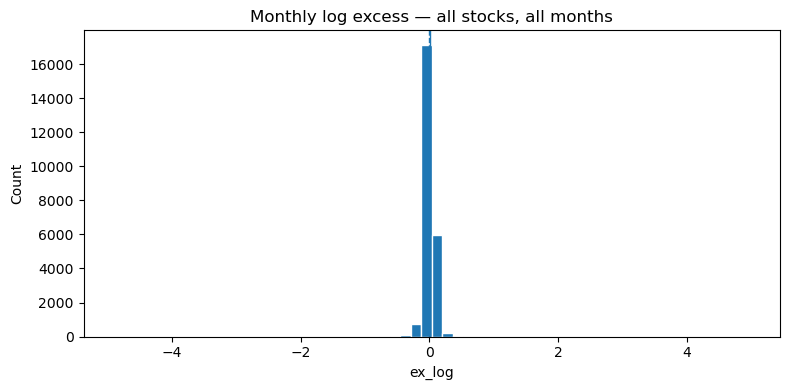

n=24,129, mean=0.0027, std=0.1059, min=-4.8772, max=4.9547


In [18]:
# ex_log histogram

# Clean finite values
x = returns_monthly["ex_log"].replace([np.inf, -np.inf], np.nan).dropna()

plt.figure(figsize=(8,4))
plt.hist(x, bins=60, edgecolor="white")
plt.axvline(0.0, linestyle="--", linewidth=1)
plt.axvline(x.mean(), linestyle="-", linewidth=1)
plt.title("Monthly log excess — all stocks, all months")
plt.xlabel("ex_log")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(f"n={len(x):,}, mean={x.mean():.4f}, std={x.std(ddof=0):.4f}, "
      f"min={x.min():.4f}, max={x.max():.4f}")


In [20]:
print(f"\nSaved dataset tag = '{TAG}'")
print("File names:")
print(" ", out("snp500_monthly_with_log_returns.parquet").name)
print(" ", out("ftse_monthly_with_log_returns.parquet").name)
print(" ", out("equities_monthly_with_log_returns.parquet").name)
print(" ", out("returns_monthly_stocks.parquet").name)



Saved dataset tag = '1b'
File names:
  snp500_monthly_with_log_returns_1b.parquet
  ftse_monthly_with_log_returns_1b.parquet
  equities_monthly_with_log_returns_1b.parquet
  returns_monthly_stocks_1b.parquet
